In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
import pandas as pd
import os
# Define the dataset path using your absolute file path
dataset_path = r"C:\Users\Sandrex\OneDrive\Desktop\comprog_lab\Lab7_DataVisualization_Dala\spotify_top_1000_tracks.csv"
# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")
# Convert release_date and extract year
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
# FIX: We REMOVE the line that tried to create 'duration_min'
# because it already exists in the CSV file you loaded.
# (The 'duration_min' column is ready for use!)
print(" Dataset loaded and basic preprocessing complete!")
print(df.head(3))

 Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [12]:
import numpy as np
# Clean up text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()
df['album'] = df['album'].str.strip()
# Convert 'year' to integer
df['year'] = df['year'].fillna(0).astype(int)
# Drop unnecessary columns
cols_to_drop = ['spotify_url', 'id', 'release_date']
# Check for and add other common audio feature columns if they exist
if 'time_signature' in df.columns:
 cols_to_drop.append('time_signature')
if 'key' in df.columns:
 cols_to_drop.append('key')
if 'mode' in df.columns:
 cols_to_drop.append('mode')
df = df.drop(columns=cols_to_drop, errors='ignore')
# Feature Engineering: Tempo Category
tempo_bins = [0, 100, 140, np.inf]
tempo_labels = ['Slow', 'Medium', 'Fast']
if 'tempo' in df.columns:
 df['tempo_category'] = pd.cut( # Create tempo category column
 df['tempo'], bins=tempo_bins,
 labels=tempo_labels, right=False
 )
 print("Feature 'tempo_category' created.")
else:
 print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.")
# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first')
print(f" Data cleaning and feature engineering complete.")
print(f"Final Row Count after deduplication: {len(df)}")

 Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
student_name = "Sandrex J. Dala"
student_id = "TUPM-25-3410" # Replace with your actual ID
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5)
% 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4)
% 256:02x}"

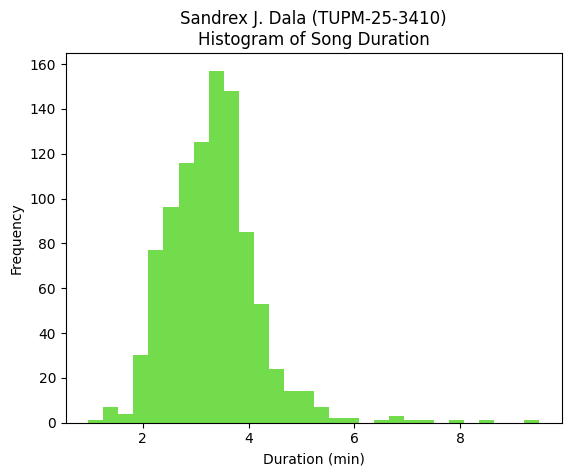

In [14]:
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7)
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\2022922137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


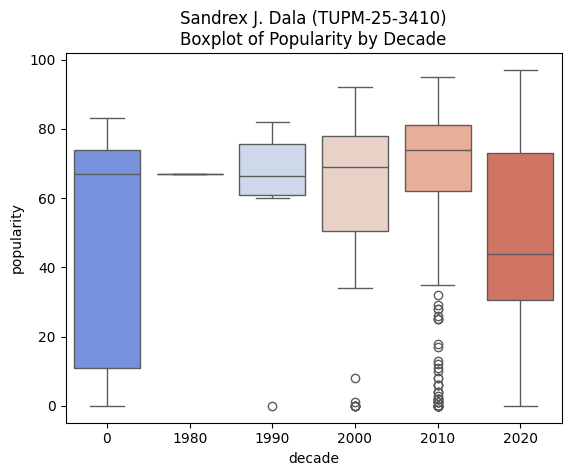

In [15]:
df['decade'] = (df['year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade")
plt.show()

C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\2607157399.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


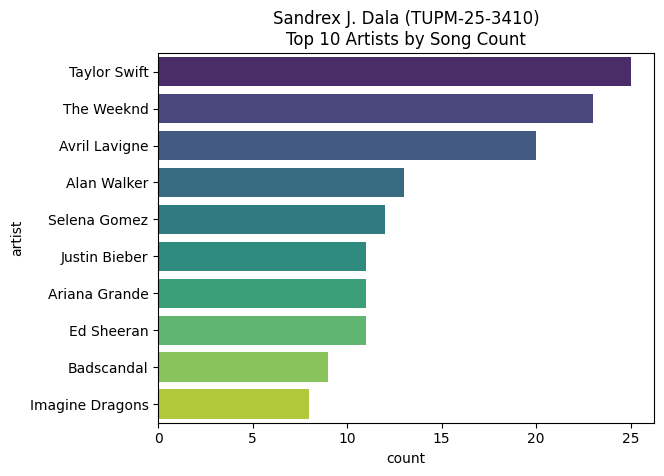

In [16]:
sns.countplot(y='artist', data=df,
order=df['artist'].value_counts().head(10).index, palette='viridis')
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count")
plt.show()

C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\3035391425.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',
C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\3035391425.py:1: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',


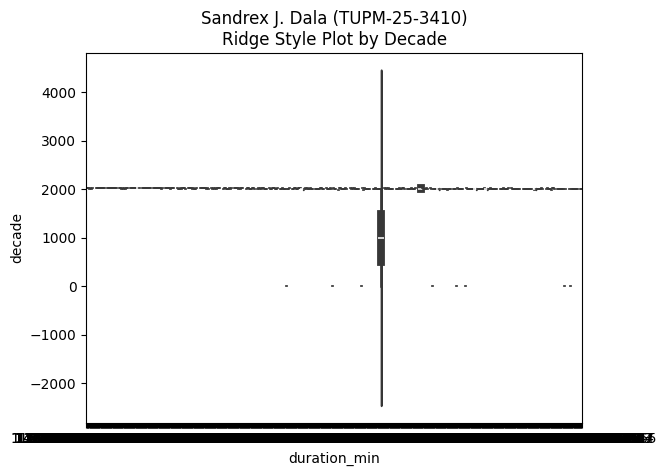

In [17]:
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm',
scale='width')
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade")
plt.show()

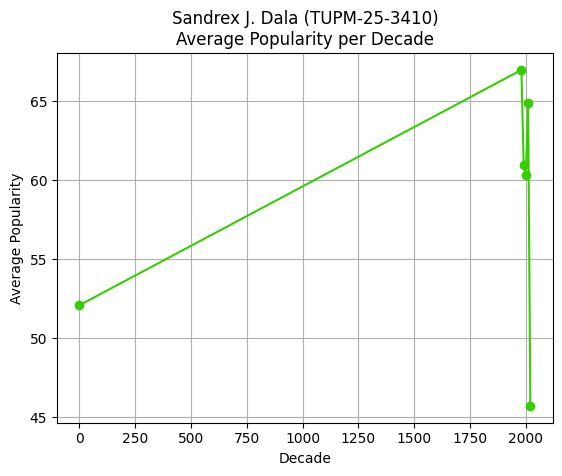

In [18]:
avg_pop = df.groupby('decade')['popularity'].mean()
avg_pop.plot(kind='line', color=color1, marker='o')
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade")
plt.xlabel('Decade')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

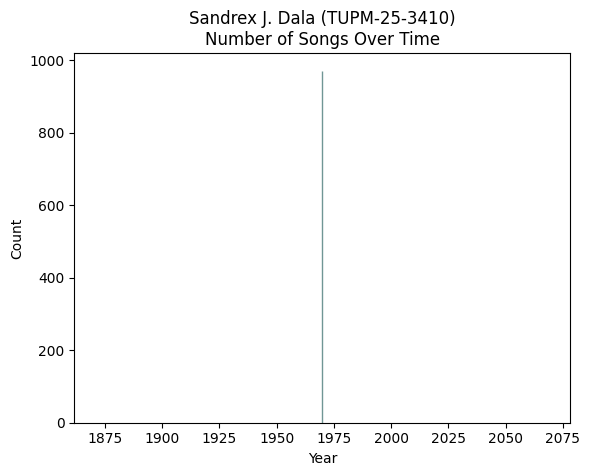

In [19]:
df['release_year'] = pd.to_datetime(df['year'], errors='coerce').dt.year 
count_by_year = df['release_year'].value_counts().sort_index() 
count_by_year.plot(kind='area', color=color2, alpha=0.7) 

plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time") 

plt.xlabel('Year') 
plt.ylabel('Count') 
plt.show()

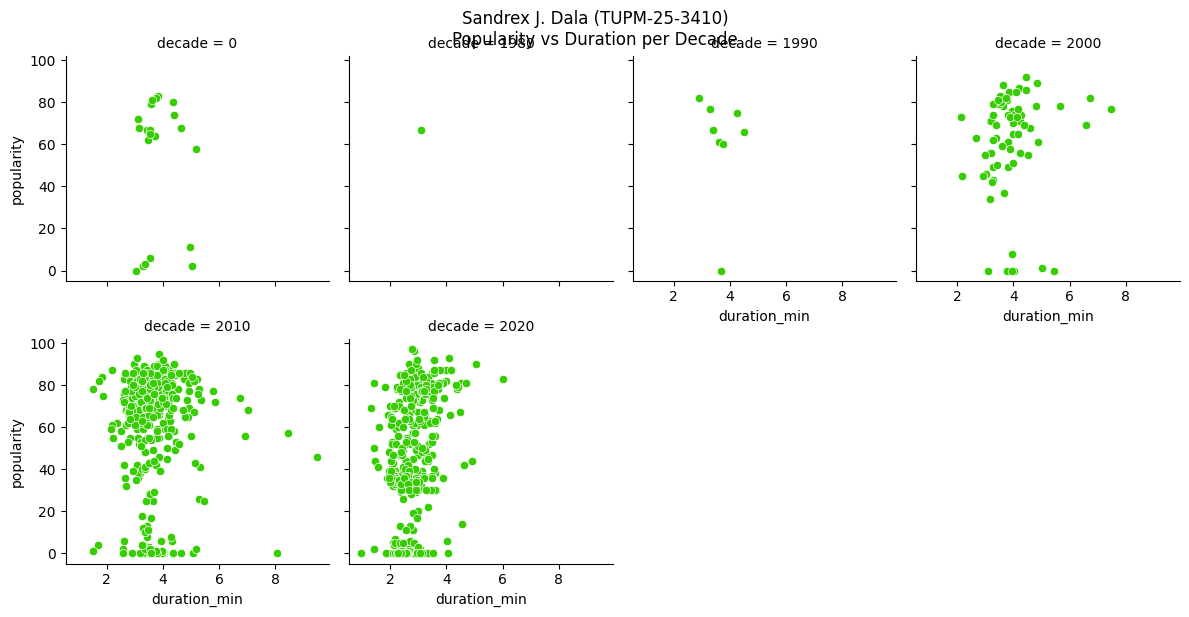

In [20]:
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', 
color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show() 

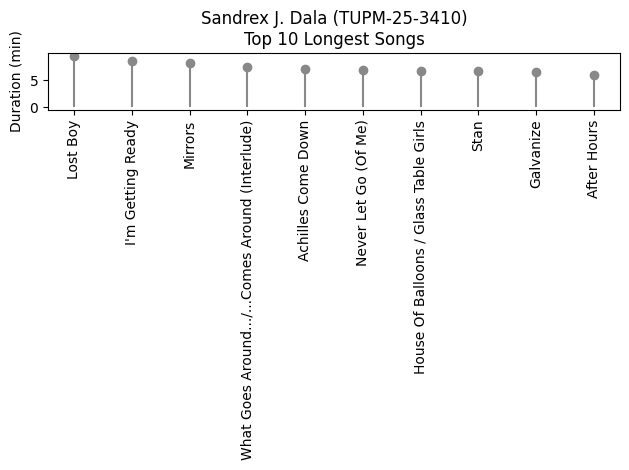

In [21]:
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 

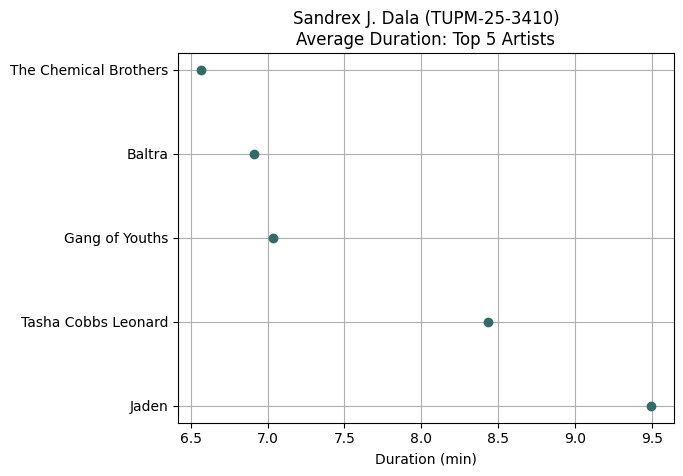

In [22]:
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show()

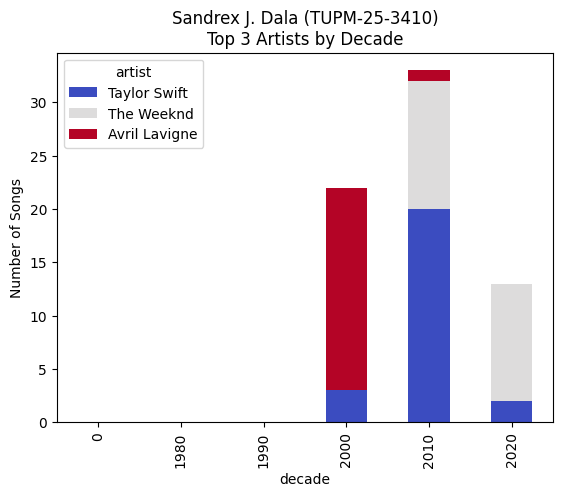

In [23]:
crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show()

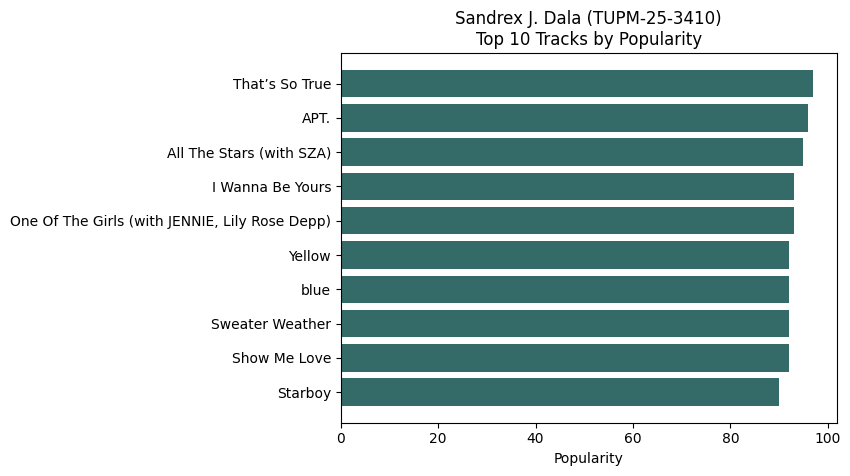

In [24]:
top_tracks = df.nlargest(10, 'popularity') 
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color2) 
plt.xlabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity") 
plt.gca().invert_yaxis() 
plt.show()

C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\1577435667.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])
C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\1577435667.py:2: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888'])


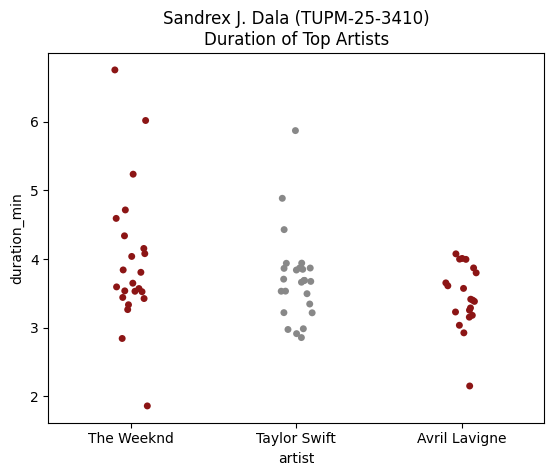

In [25]:
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show()

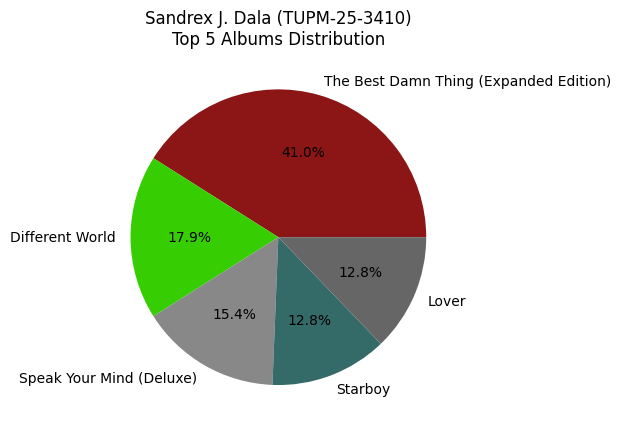

In [26]:
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show()

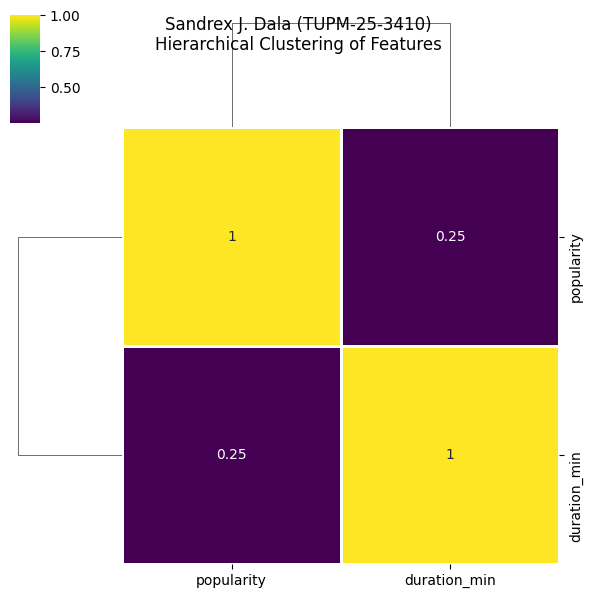

In [27]:
numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show() 

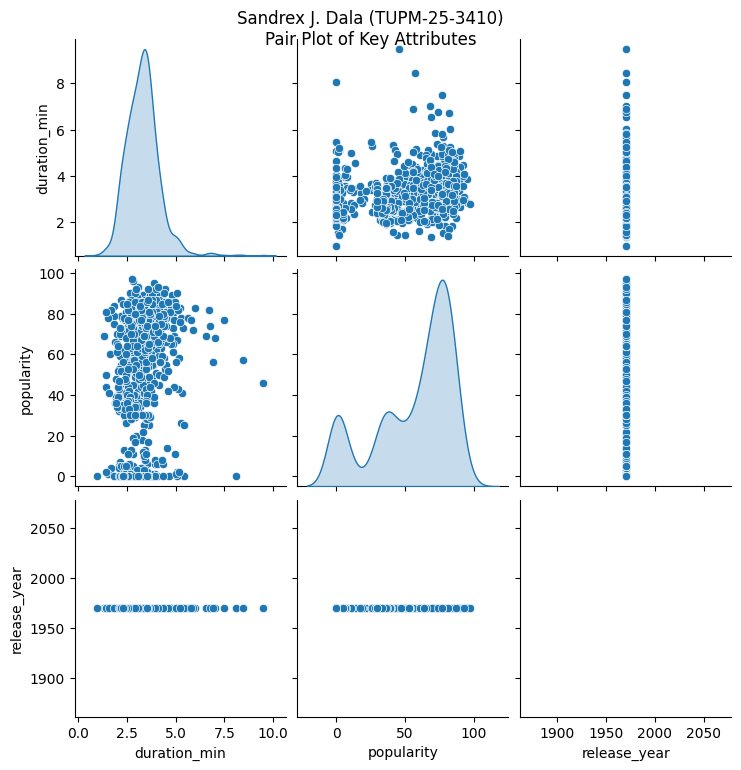

In [28]:
sns.pairplot(df[['duration_min', 'popularity', 'release_year']],
diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes", y=1.02)
plt.show()


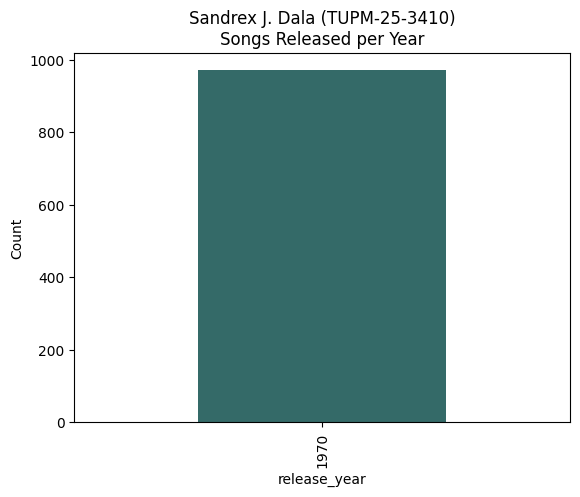

In [29]:
df['release_year'].value_counts().sort_index().plot(kind='bar',
color=color2)
plt.title(f"{student_name} ({student_id})\nSongs Released per Year")
plt.ylabel('Count')
plt.show()

C:\Users\Sandrex\AppData\Local\Temp\ipykernel_36620\782068081.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


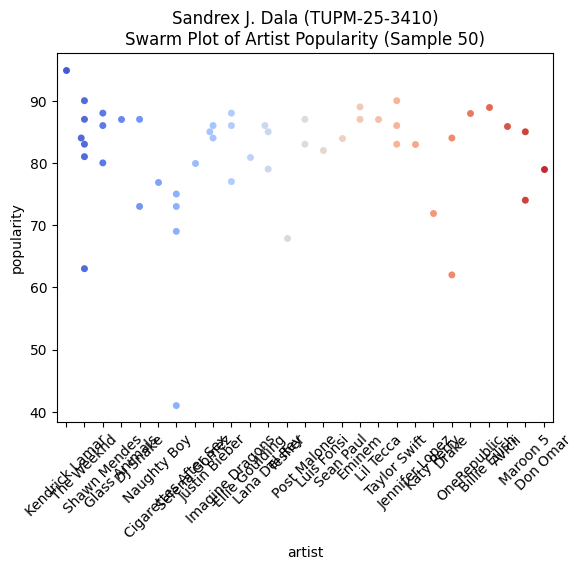

In [30]:
sns.swarmplot(data=df.head(50), x='artist', y='popularity',
palette='coolwarm')
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)
plt.show()

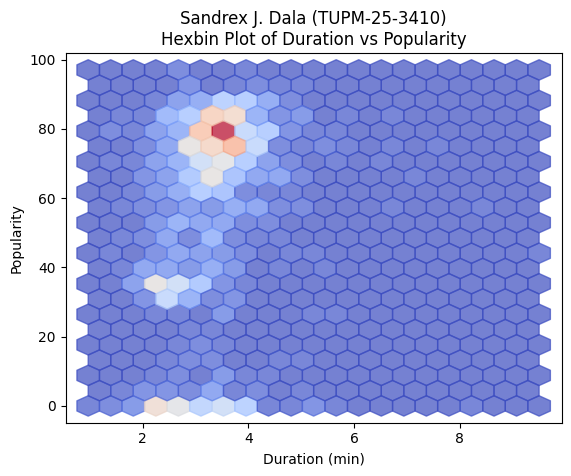

In [31]:
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20,
cmap='coolwarm', alpha=0.7)
plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")
plt.show()

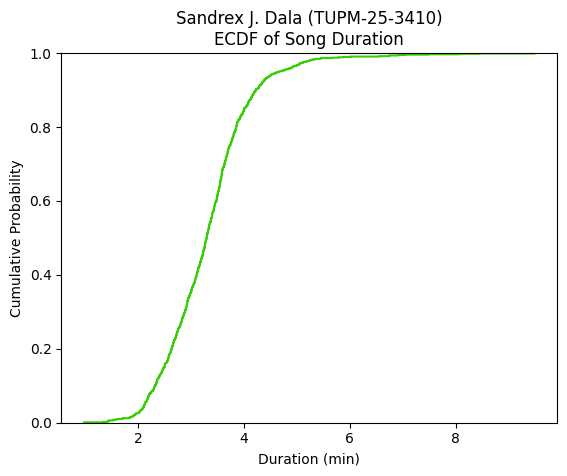

In [32]:
sns.ecdfplot(data=df, x='duration_min', color=color1)
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel('Duration (min)')
plt.ylabel('Cumulative Probability')
plt.show()

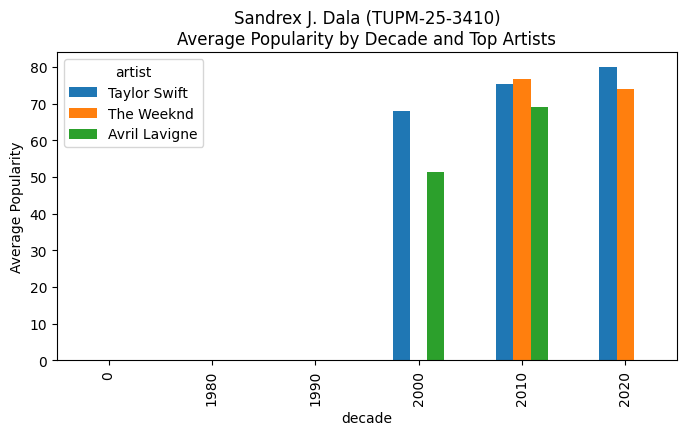

In [33]:
avg_artist_decade = df.groupby(['decade','artist'])['popularity'].mean().unstack().fillna(0)
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4))
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel('Average Popularity')
plt.show()